# Evaluations for all models

REPO_ROOT  = E:\A1_last_version
RESULT_DIR = E:\A1_last_version\results
PLOT_DIR   = E:\A1_last_version\plots\evaluation_plots

Loaded models: ['Model1_FFT_MLP_All', 'Model2_FFT_MLP_IMU_THM', 'Model3_CNN_BiLSTM_TOF', 'Model4_Late_Fusion', 'Model5_Intermediate_Fusion', 'Model6_FFT_Random_Forest']


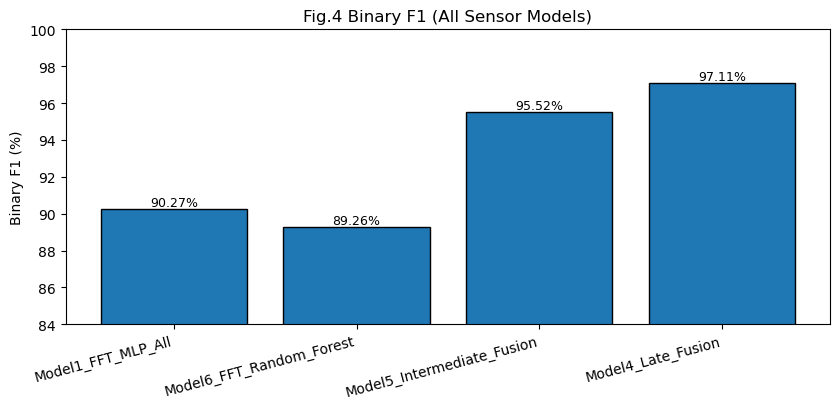

Saved: E:\A1_last_version\plots\evaluation_plots\binaryF1_all_sensor_models.png


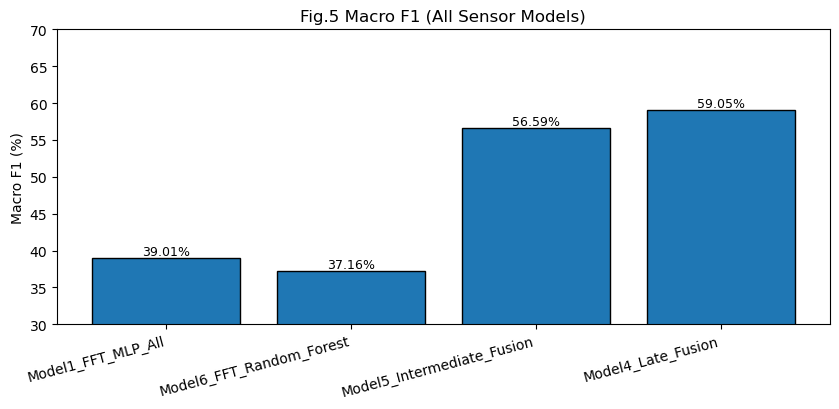

Saved: E:\A1_last_version\plots\evaluation_plots\macroF1_all_sensor_models.png


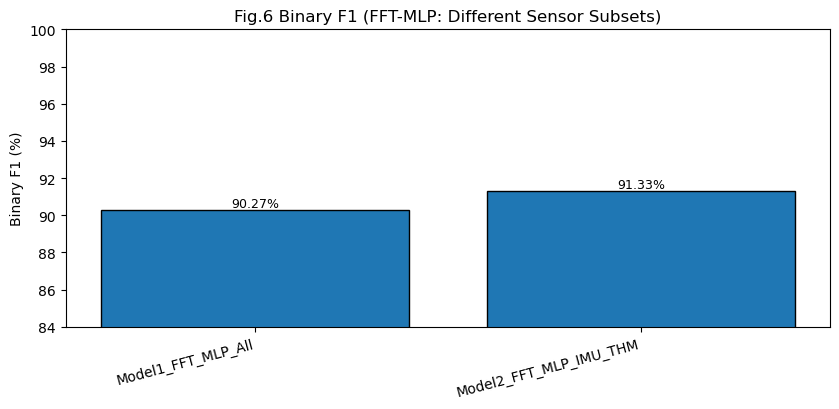

Saved: E:\A1_last_version\plots\evaluation_plots\binaryF1_fft_subsets.png


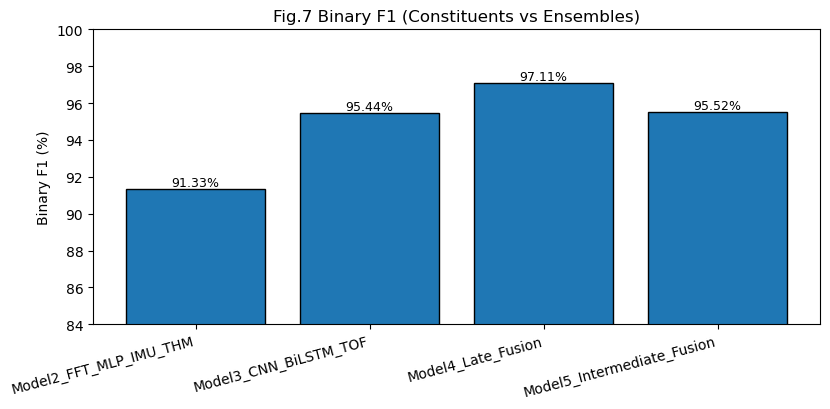

Saved: E:\A1_last_version\plots\evaluation_plots\binaryF1_constituents_vs_ensembles.png


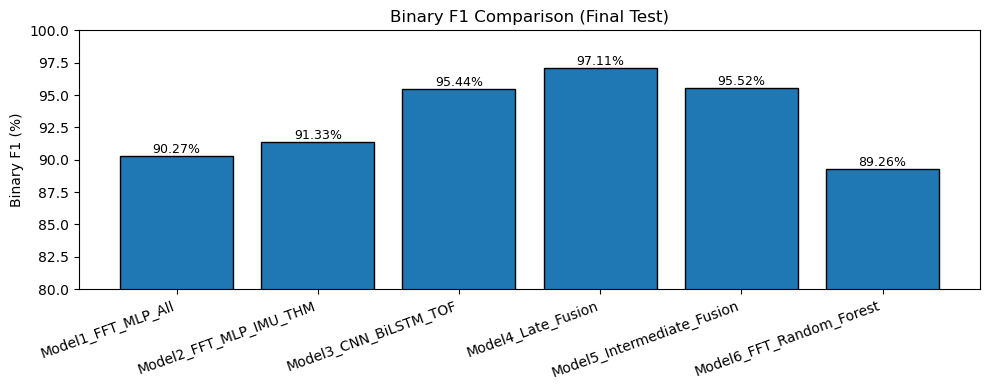

Saved: E:\A1_last_version\plots\evaluation_plots\binaryF1_comparison.png


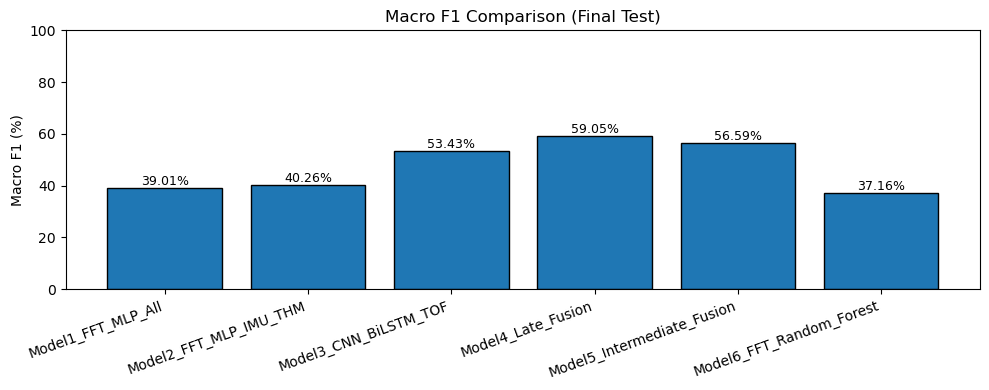

Saved: E:\A1_last_version\plots\evaluation_plots\macroF1_comparison.png


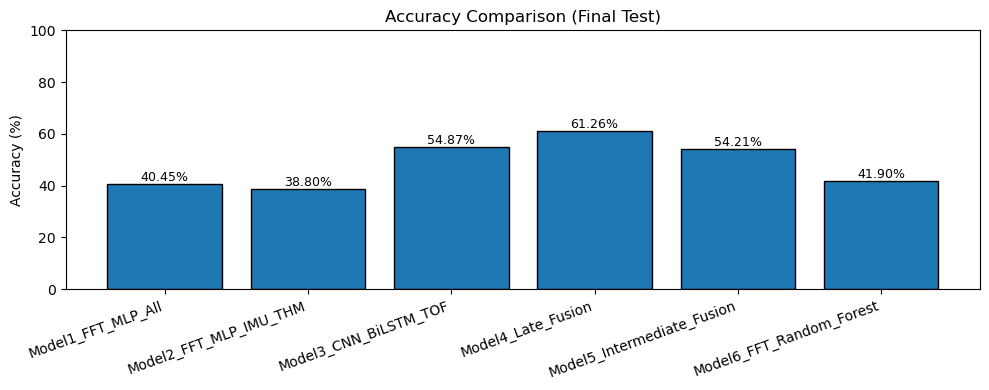

Saved: E:\A1_last_version\plots\evaluation_plots\accuracy_comparison.png


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

# 
# Find repo root robustly 
# 
from pathlib import Path

def find_repo_root(start: Path):
    cur = start.resolve()
    for _ in range(20):
        if (cur / "data").exists() and (cur / "notebooks").exists():
            return cur
        cur = cur.parent
    raise RuntimeError("Cannot find repo root containing BOTH 'data/' and 'notebooks/'.")

REPO_ROOT = find_repo_root(Path.cwd())

RESULT_DIR = REPO_ROOT / "results"
PLOT_DIR = REPO_ROOT / "plots" / "evaluation_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT  =", REPO_ROOT)
print("RESULT_DIR =", RESULT_DIR)
print("PLOT_DIR   =", PLOT_DIR)

# 
# Register model summary paths
#
MODEL_SUMMARIES = {
    "Model1_FFT_MLP_All": RESULT_DIR / "Model1_Training" / "model1_training_summary.json",
    "Model2_FFT_MLP_IMU_THM": RESULT_DIR / "Model2_Training" / "model2_training_summary.json",
    "Model3_CNN_BiLSTM_TOF": RESULT_DIR / "Model3_Training" / "model3_training_summary.json",
    "Model4_Late_Fusion": RESULT_DIR / "Model4_Training" / "model4_training_summary.json",
    "Model5_Intermediate_Fusion": RESULT_DIR / "Model5_Training" / "model5_training_summary.json",
    "Model6_FFT_Random_Forest": RESULT_DIR / "Model6_Training" / "model6_training_summary.json",
}

PLOT_ORDER = list(MODEL_SUMMARIES.keys())

#
# Load metrics
# 
def load_metrics_any_format(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    if "final_metrics" in obj and isinstance(obj["final_metrics"], dict):
        m = obj["final_metrics"]

    elif "metrics" in obj and isinstance(obj["metrics"], dict):
        m = obj["metrics"]
    elif "test_metrics" in obj and isinstance(obj["test_metrics"], dict):
        m = obj["test_metrics"]

   
    elif "best_metrics" in obj and isinstance(obj["best_metrics"], dict):
        m = obj["best_metrics"]
    elif "best_macro" in obj and isinstance(obj["best_macro"], dict):
        m = obj["best_macro"]

   
    elif all(k in obj for k in ["acc", "macroF1", "binaryF1"]):
        m = obj

    else:
        raise KeyError(f"Cannot find metrics dict in {path}. Top keys: {list(obj.keys())}")

   
    def pick_key(d, candidates):
        for k in candidates:
            if k in d:
                return d[k]
        raise KeyError(f"Missing keys {candidates} in {path}. Available: {list(d.keys())}")

    acc = pick_key(m, ["acc", "accuracy"])
    macro = pick_key(m, ["macroF1", "macro_f1", "macro"])
    binary = pick_key(m, ["binaryF1", "binary_f1", "binary"])

    return {"acc": float(acc), "macroF1": float(macro), "binaryF1": float(binary)}

collected = {}
for name in PLOT_ORDER:
    p = MODEL_SUMMARIES[name]
    if not p.exists():
        print("[MISS]", p)
        continue
    try:
        collected[name] = load_metrics_any_format(p)
    except Exception as e:
        print(f"[WARN] Failed to load {name}: {p}\n  -> {e}")

if not collected:
    raise FileNotFoundError(
        f"No valid summary json loaded under {RESULT_DIR}. "
        "Make sure your json files are saved in REPO_ROOT/results/ModelX_Training/..."
    )

print("\nLoaded models:", list(collected.keys()))

# 
# Plot helper
# 
def plot_metric(collected_metrics, metric_key, title, ylabel, save_path, y_min=None, y_max=None):
    names = [n for n in PLOT_ORDER if n in collected_metrics]
    vals = [collected_metrics[n][metric_key] * 100 for n in names]

    plt.figure(figsize=(10, 4))
    bars = plt.bar(names, vals, edgecolor="black", linewidth=1.0)

    plt.title(title)
    plt.ylabel(f"{ylabel} (%)")
    plt.xticks(rotation=20, ha="right")

    for bar, val in zip(bars, vals):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)
    else:
        plt.ylim(0, max(vals) * 1.15)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

# 
# Paper-style 4 result figures (Fig.4–Fig.7)
# 

def plot_metric_subset(collected_metrics, names, metric_key,
                       title, ylabel, save_path,
                       y_min=None, y_max=None):
    names_ok = [n for n in names if n in collected_metrics]
    if len(names_ok) == 0:
        print("[SKIP] No available models for:", title)
        return

    vals = [collected_metrics[n][metric_key] * 100 for n in names_ok]

    plt.figure(figsize=(8.5, 4.2))
    bars = plt.bar(names_ok, vals, edgecolor="black", linewidth=1.0)

    plt.title(title)
    plt.ylabel(f"{ylabel} (%)")
    plt.xticks(rotation=15, ha="right")

    # annotate values on bars
    for bar, val in zip(bars, vals):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)
    else:
        plt.ylim(0, max(vals) * 1.15)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)


# ---- Define 4 paper figure groups ----
# Fig: "models trained on all sensor data"
FIG45_MODELS = [
    "Model1_FFT_MLP_All",
    "Model6_FFT_Random_Forest",
    "Model5_Intermediate_Fusion",
    "Model4_Late_Fusion",
]

# Fig: FFT-MLP with different subsets of sensor data

FIG6_MODELS = [
    "Model1_FFT_MLP_All",        
    "Model2_FFT_MLP_IMU_THM",     
    "Model0_FFT_MLP_IMU_ONLY", 
]

# Fig： constituents vs ensembles
FIG7_MODELS = [
    "Model2_FFT_MLP_IMU_THM",
    "Model3_CNN_BiLSTM_TOF",
    "Model4_Late_Fusion",
    "Model5_Intermediate_Fusion",
]


# Generate the 7 figures
# Fig: Binary F1 (84–100)
plot_metric_subset(
    collected, FIG45_MODELS, "binaryF1",
    "Fig.4 Binary F1 (All Sensor Models)", "Binary F1",
    PLOT_DIR / "binaryF1_all_sensor_models.png",
    y_min=84, y_max=100
)

# Fig: Macro F1 (30–70)
plot_metric_subset(
    collected, FIG45_MODELS, "macroF1",
    "Fig.5 Macro F1 (All Sensor Models)", "Macro F1",
    PLOT_DIR / "macroF1_all_sensor_models.png",
    y_min=30, y_max=70
)

# Fig: Binary F1 (84–100)
plot_metric_subset(
    collected, FIG6_MODELS, "binaryF1",
    "Fig.6 Binary F1 (FFT-MLP: Different Sensor Subsets)", "Binary F1",
    PLOT_DIR / "binaryF1_fft_subsets.png",
    y_min=84, y_max=100
)

# Fig: Binary F1 (84–100)
plot_metric_subset(
    collected, FIG7_MODELS, "binaryF1",
    "Fig.7 Binary F1 (Constituents vs Ensembles)", "Binary F1",
    PLOT_DIR / "binaryF1_constituents_vs_ensembles.png",
    y_min=84, y_max=100
)
plot_metric(
    collected, "binaryF1",
    "Binary F1 Comparison (Final Test)", "Binary F1",
    PLOT_DIR / "binaryF1_comparison.png",
    y_min=80, y_max=100
)

plot_metric(
    collected, "macroF1",
    "Macro F1 Comparison (Final Test)", "Macro F1",
    PLOT_DIR / "macroF1_comparison.png",
    y_min=0, y_max=100
)

plot_metric(
    collected, "acc",
    "Accuracy Comparison (Final Test)", "Accuracy",
    PLOT_DIR / "accuracy_comparison.png",
    y_min=0, y_max=100
)


REPO_ROOT = E:\A1_last_version
RESULT_DIR = E:\A1_last_version\results
PLOT_DIR = E:\A1_last_version\plots\evaluation_plots
TOF_Only Time_series Transformer Model loaded:
  Binary F1 = 93.36
  Macro F1  = 47.92
LSTM_Attention Model loaded:
  Binary F1 = 97.26
  Macro F1  = 60.09
TOF_Only Token LSTM Model loaded:
  Binary F1 = 84.75
  Macro F1  = 28.56
TOF_Only_CNN_Toker_LSTM Model loaded:
  Binary F1 = 95.16
  Macro F1  = 60.71


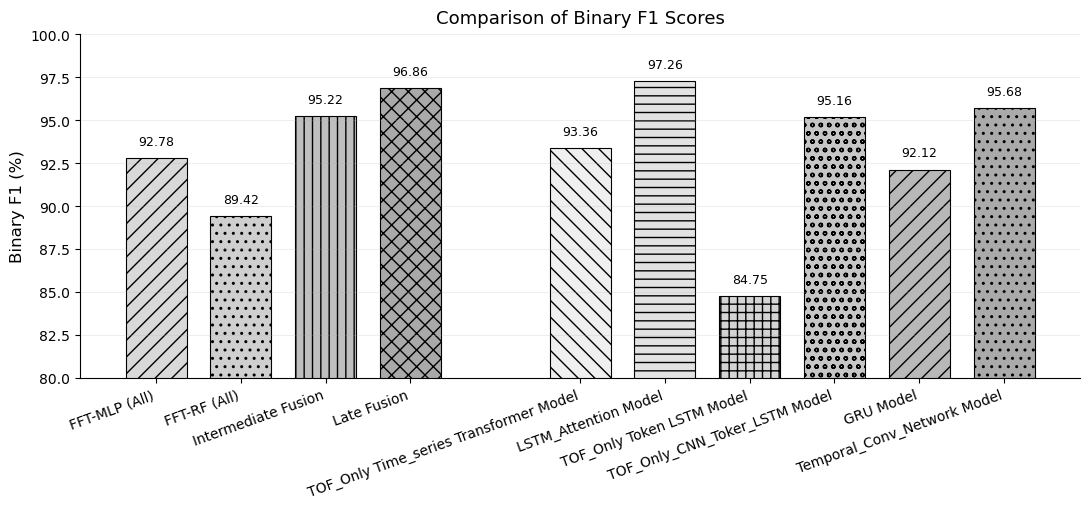

Saved binary plot to: E:\A1_last_version\plots\evaluation_plots\model7_to_12_vs_baselines_binary_f1.png


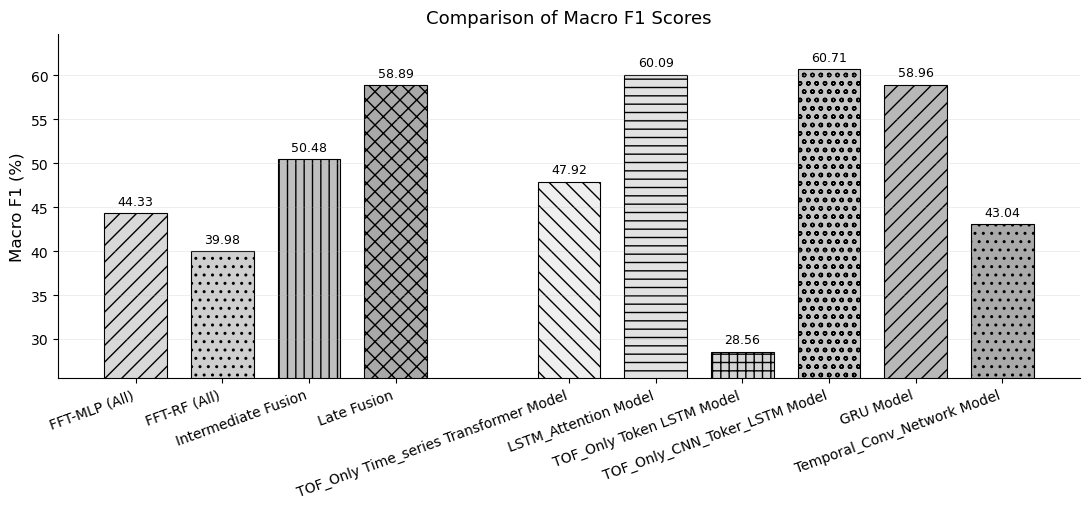

Saved macro plot to: E:\A1_last_version\plots\evaluation_plots\model7_to_12_vs_baselines_macro_f1.png

========== Binary F1 Results ==========
FFT-MLP (All): 92.78%
FFT-RF (All): 89.42%
Intermediate Fusion: 95.22%
Late Fusion: 96.86%
TOF_Only Time_series Transformer Model: 93.36%
LSTM_Attention Model: 97.26%
TOF_Only Token LSTM Model: 84.75%
TOF_Only_CNN_Toker_LSTM Model: 95.16%
GRU Model: 92.12%
Temporal_Conv_Network Model: 95.68%

========== Macro F1 Results ==========
FFT-MLP (All): 44.33%
FFT-RF (All): 39.98%
Intermediate Fusion: 50.48%
Late Fusion: 58.89%
TOF_Only Time_series Transformer Model: 47.92%
LSTM_Attention Model: 60.09%
TOF_Only Token LSTM Model: 28.56%
TOF_Only_CNN_Toker_LSTM Model: 60.71%
GRU Model: 58.96%
Temporal_Conv_Network Model: 43.04%


In [3]:
import json
from pathlib import Path

import matplotlib.pyplot as plt


# 1) Find repo root

NOTEBOOK_DIR = Path.cwd()

def find_repo_root(start: Path):
    cur = start.resolve()
    for _ in range(20):
        if (cur / "results").exists() or (cur / ".git").exists():
            return cur
        cur = cur.parent
    return start.resolve()

REPO_ROOT = find_repo_root(NOTEBOOK_DIR)

RESULT_DIR = REPO_ROOT / "results"
PLOT_DIR = REPO_ROOT / "plots" / "evaluation_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT =", REPO_ROOT)
print("RESULT_DIR =", RESULT_DIR)
print("PLOT_DIR =", PLOT_DIR)

paper_binary = {
    "FFT-MLP (All)": 92.78,
    "FFT-RF (All)": 89.42,
    "Intermediate Fusion": 95.22,
    "Late Fusion": 96.86,
}

paper_macro = {
    "FFT-MLP (All)": 44.33,
    "FFT-RF (All)": 39.98,
    "Intermediate Fusion": 50.48,
    "Late Fusion": 58.89,
}


# 3) Model 7-12 display names

MODEL_DISPLAY_NAMES = {
    "Model 7": "GRU Model",
    "Model 8": "TOF_Only Time_series Transformer Model",
    "Model 9": "LSTM_Attention Model",
    "Model 10": "Temporal_Conv_Network Model",
    "Model 11": "TOF_Only Token LSTM Model",
    "Model 12": "TOF_Only_CNN_Toker_LSTM Model",
}

# 4) Summary paths

MODEL_SUMMARIES = {
    "Model 8": RESULT_DIR / "Model8_Training" / "model8_training_summary.json",
    "Model 9": RESULT_DIR / "Model9_Training" / "model9_training_summary.json",
    "Model 11": RESULT_DIR / "Model11_Training" / "model11_training_summary.json",
    "Model 12": RESULT_DIR / "Model12_Training" / "model12_training_summary.json",
}


manual_binary = {
    "Model 7": 0.9211873080859775,  
    "Model 10": 0.9567531603459747,  
}

manual_macro = {
    "Model 7": 0.5895604437108855,   
    "Model 10":0.4303794227787749,  
}




# 6) Load json models

nlp_binary = {}
nlp_macro = {}

for model_key, summary_path in MODEL_SUMMARIES.items():
    if not summary_path.exists():
        print(f"[Warning] Missing file: {summary_path}")
        continue

    try:
        with open(summary_path, "r", encoding="utf-8") as f:
            summary = json.load(f)

        final_metrics = summary.get("final_metrics", {})
        binary_f1 = final_metrics.get("binaryF1", None)
        macro_f1 = final_metrics.get("macroF1", None)

        if binary_f1 is None or macro_f1 is None:
            print(f"[Warning] Missing metric(s) in: {summary_path}")
            continue

        if binary_f1 <= 1:
            binary_f1 *= 100
        if macro_f1 <= 1:
            macro_f1 *= 100

        display_name = MODEL_DISPLAY_NAMES.get(model_key, model_key)
        nlp_binary[display_name] = binary_f1
        nlp_macro[display_name] = macro_f1

        print(f"{display_name} loaded:")
        print(f"  Binary F1 = {binary_f1:.2f}")
        print(f"  Macro F1  = {macro_f1:.2f}")

    except Exception as e:
        print(f"[Error] Failed to load {summary_path}: {e}")


# 7) Add manual Model 7 and Model 10

for model_key, value in manual_binary.items():
    if value is None:
        continue
    if value <= 1:
        value *= 100
    display_name = MODEL_DISPLAY_NAMES.get(model_key, model_key)
    nlp_binary[display_name] = value

for model_key, value in manual_macro.items():
    if value is None:
        continue
    if value <= 1:
        value *= 100
    display_name = MODEL_DISPLAY_NAMES.get(model_key, model_key)
    nlp_macro[display_name] = value


# 8) Merge results

all_binary = {}
all_binary.update(paper_binary)
all_binary.update(nlp_binary)

all_macro = {}
all_macro.update(paper_macro)
all_macro.update(nlp_macro)

# 9) Plot helper

def plot_metric_comparison(metric_dict, title, ylabel, save_path, ylim=None):
    labels = list(metric_dict.keys())
    values = list(metric_dict.values())

  
    x = [0, 1, 2, 3, 5, 6, 7, 8, 9, 10][:len(labels)]

    plt.figure(figsize=(11, 5.2))

    
    colors = [
        "#d9d9d9", "#cfcfcf", "#bfbfbf", "#a9a9a9",
        "#efefef", "#e2e2e2", "#d4d4d4", "#c6c6c6", "#b8b8b8", "#aaaaaa"
    ][:len(labels)]

    hatches = [
        "//", "..", "||", "xx",
        "\\\\", "--", "++", "oo", "//", ".."
    ][:len(labels)]

    bars = []
    for i in range(len(labels)):
        bar = plt.bar(
            x[i],
            values[i],
            width=0.72,
            color=colors[i],
            edgecolor="black",
            linewidth=0.8,
            hatch=hatches[i]
        )
        bars.append(bar[0])

    
    plt.title(title, fontsize=13, pad=8)
    plt.ylabel(ylabel, fontsize=12)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xticks(x, labels, rotation=20, ha="right", fontsize=10)
    plt.yticks(fontsize=10)

   
    plt.grid(axis="y", linestyle="-", linewidth=0.5, alpha=0.3)

   
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    
    for bar, v in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.6,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )
  

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# 10) Draw Binary F1

binary_plot_path = PLOT_DIR / "model7_to_12_vs_baselines_binary_f1.png"
plot_metric_comparison(
    metric_dict=all_binary,
    title="Comparison of Binary F1 Scores",
    ylabel="Binary F1 (%)",
    save_path=binary_plot_path,
    ylim=(80, 100)
)
print("Saved binary plot to:", binary_plot_path)


# 11) Draw Macro F1

macro_min = min(all_macro.values())
macro_max = max(all_macro.values())
macro_plot_path = PLOT_DIR / "model7_to_12_vs_baselines_macro_f1.png"
plot_metric_comparison(
    metric_dict=all_macro,
    title="Comparison of Macro F1 Scores",
    ylabel="Macro F1 (%)",
    save_path=macro_plot_path,
    ylim=(max(0, macro_min - 3), macro_max + 4)
)

print("Saved macro plot to:", macro_plot_path)


# 12) Print summary

print("\n========== Binary F1 Results ==========")
for k, v in all_binary.items():
    print(f"{k}: {v:.2f}%")

print("\n========== Macro F1 Results ==========")
for k, v in all_macro.items():
    print(f"{k}: {v:.2f}%")